In [1]:
import scanpy as sc
import rapids_singlecell as rsc

import pandas as pd
from scipy import stats as sp_stats
import numpy as np
import seaborn as sns
from matplotlib import pyplot as plt
from h5py import File
from anndata.io import read_elem

In [2]:
latent_X = np.load("/data/iterative_scanvi_results/iterative_scANVI_output/scANVI_models/db5201ecbe0da4fef698bea9e8803047/X_scVI.npy")

In [3]:
iter_scanvi_results = pd.read_csv("/data/iterative_scanvi_results/iterative_scANVI_output/iterative_scANVI_results.2025-06-23.csv", index_col = 0)

In [4]:
obs_names = pd.read_csv("/data/iterative_scanvi_results/iterative_scANVI_output/scANVI_models/db5201ecbe0da4fef698bea9e8803047/obs_names.csv", header = None, names = ["obs"])
var_names = pd.read_csv("/data/iterative_scanvi_results/iterative_scANVI_output/scANVI_models/db5201ecbe0da4fef698bea9e8803047/var_names.csv", header = None, names = ["var"])
obs_probs = pd.read_csv("/data/iterative_scanvi_results/iterative_scANVI_output/scANVI_models/db5201ecbe0da4fef698bea9e8803047/probabilities.csv",index_col = 0)

In [5]:
latent_adata = sc.AnnData(X = latent_X, obs = obs_probs)

In [6]:
latent_adata.obs[iter_scanvi_results.columns] = iter_scanvi_results

In [7]:
rsc.get.anndata_to_GPU(latent_adata)

In [8]:
rsc.pp.neighbors(latent_adata)

In [9]:
rsc.tl.leiden(latent_adata, resolution = 2)

In [10]:
rsc.tl.umap(latent_adata)

In [11]:
rsc.get.anndata_to_CPU(latent_adata)

In [12]:
latent_adata.obs["dataset"] = latent_adata.obs["Class"].apply(lambda x: "SEA-AD MTG" if x!="Unknown" else "HMBA Ca")

## Figure 1F-1

... storing 'Class_scANVI' as categorical
... storing 'Class_stash' as categorical


... storing 'Class' as categorical
... storing 'dataset' as categorical
/opt/conda/lib/python3.12/site-packages/scanpy/plotting/_tools/scatterplots.py:1227: FutureWarning: The method obs_vector is deprecated and will be removed in the future. Use anndata.acc.A instead of obs_vector. E.g. `vec = adata[A.obs['foo']]` or `vec = adata[A.layers['l']['bar', :]]`
  values = adata.obs_vector(value_to_plot, layer=layer)


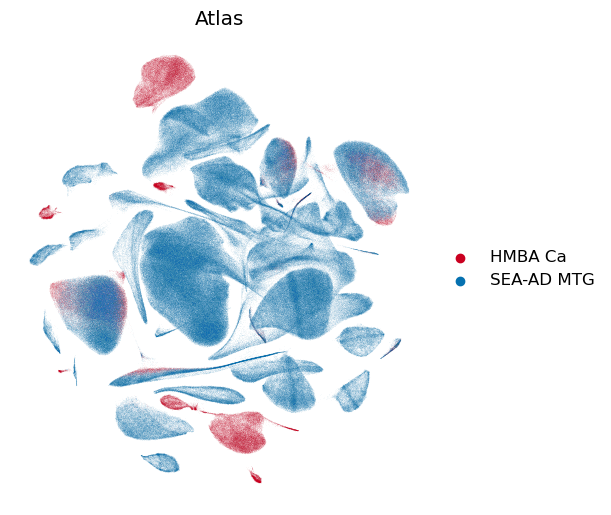

In [13]:
with plt.rc_context({"savefig.dpi":600, "figure.figsize":(6,10.5), "font.size":12, 'figure.constrained_layout.use':True}):
    fig, ax = plt.subplots()
    sc.pl.umap(latent_adata, color = "dataset", frameon = False, show = False, title = None, palette = ["#ca0020", "#0571b0"], ax = ax)
    plt.title("Atlas")
    ax.set_aspect("equal")
    plt.savefig("/scratch/figure1_dataset.png", bbox_inches="tight",)
    plt.show()

/opt/conda/lib/python3.12/site-packages/scanpy/plotting/_tools/scatterplots.py:1227: FutureWarning: The method obs_vector is deprecated and will be removed in the future. Use anndata.acc.A instead of obs_vector. E.g. `vec = adata[A.obs['foo']]` or `vec = adata[A.layers['l']['bar', :]]`
  values = adata.obs_vector(value_to_plot, layer=layer)


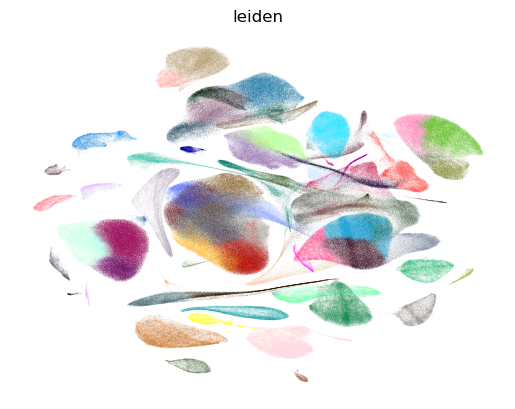

In [14]:
sc.pl.umap(latent_adata, color = "leiden", frameon = False, legend_loc = None)

In [15]:
def calculate_batch_entropy(adata, batch_key = "_scvi_batch", nn_key = 'connectivities'):
    '''
    cluster_key can be set as connectivities or distances
    where connectivities is based on simplicial set
    and distance is the top-k
    '''
    x, y = np.nonzero(adata.obsp[nn_key]) # Get the indices of the non-zero elements from knn matrix
    batch_ids = adata.obs[batch_key].factorize()[0] # Change batch ids to ordered integers
    n_cats = len(np.unique(batch_ids)) # Get the number of unique batch ids
    batch_id_array = batch_ids[y] # Convert neighbor indices to batch ids
    batch_id_split = np.split(batch_id_array, np.unique(x, return_index=True)[1][1:]) # Split the batch ids by cell (noticed that there were unequal number of neighbors for each cell)
    batch_prob_array = np.vstack([np.bincount(batch_id, minlength = n_cats) / len(batch_id) for batch_id in batch_id_split]) # Calculate the probability of each batch for each cell
    return sp_stats.entropy(batch_prob_array.T)

In [16]:
batch_entropy = calculate_batch_entropy(latent_adata, batch_key = "dataset")

In [17]:
latent_adata.obs["dataset_mixing"] = batch_entropy

/opt/conda/lib/python3.12/site-packages/scanpy/plotting/_tools/scatterplots.py:1227: FutureWarning: The method obs_vector is deprecated and will be removed in the future. Use anndata.acc.A instead of obs_vector. E.g. `vec = adata[A.obs['foo']]` or `vec = adata[A.layers['l']['bar', :]]`
  values = adata.obs_vector(value_to_plot, layer=layer)


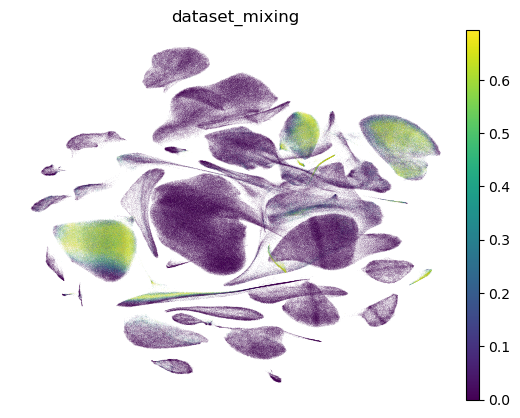

In [18]:
sc.pl.umap(latent_adata, color = "dataset_mixing", frameon = False, legend_loc = None)

In [19]:
leiden_mixing_dict = latent_adata.obs.groupby("leiden")["dataset_mixing"].mean().to_dict()

/tmp/ipykernel_9655/354733660.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  leiden_mixing_dict = latent_adata.obs.groupby("leiden")["dataset_mixing"].mean().to_dict()


In [20]:
latent_adata.obs["cluster_mixing"] = latent_adata.obs["leiden"].apply(leiden_mixing_dict.get)

In [21]:
sns.displot(latent_adata.obs.groupby("leiden")["cluster_mixing"].first(), bins = 100)
plt.axvline(0.07, color = "red", linestyle = "--")

/tmp/ipykernel_9655/392101519.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  sns.displot(latent_adata.obs.groupby("leiden")["cluster_mixing"].first(), bins = 100)


In [22]:
latent_adata.obs["mixed_cluster"] = latent_adata.obs["cluster_mixing"] > 0.075

In [23]:
latent_adata

AnnData object with n_obs × n_vars = 1570261 × 10
    obs: 'Class_scANVI', 'Class_conf_scANVI', 'Neuronal: GABAergic', 'Neuronal: Glutamatergic', 'Non-neuronal and Non-neural', 'Class_stash', 'Class', 'leiden', 'dataset', 'dataset_mixing', 'cluster_mixing', 'mixed_cluster'
    uns: 'neighbors', 'leiden', 'umap', 'dataset_colors', 'leiden_colors'
    obsm: 'X_umap'
    obsp: 'distances', 'connectivities'
    layers: None (.X)

/opt/conda/lib/python3.12/site-packages/scanpy/plotting/_tools/scatterplots.py:1227: FutureWarning: The method obs_vector is deprecated and will be removed in the future. Use anndata.acc.A instead of obs_vector. E.g. `vec = adata[A.obs['foo']]` or `vec = adata[A.layers['l']['bar', :]]`
  values = adata.obs_vector(value_to_plot, layer=layer)


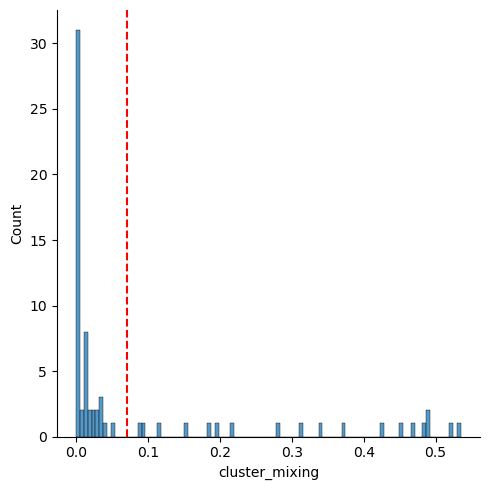

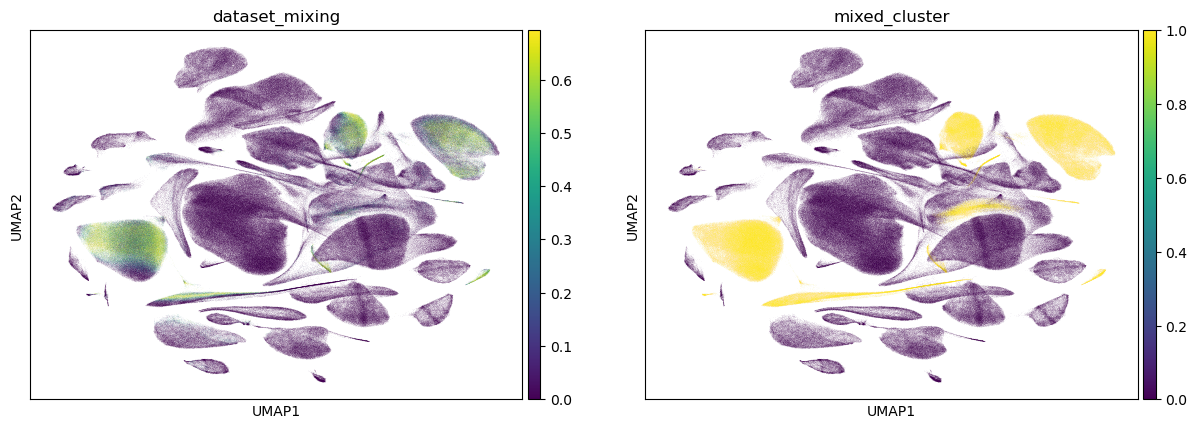

In [24]:
sc.pl.umap(latent_adata, color = ["dataset_mixing", "mixed_cluster"], sort_order = False)

In [25]:
latent_adata_subset = latent_adata[latent_adata.obs["mixed_cluster"]]

In [26]:
latent_adata_subset.obs["Class_scANVI"].value_counts()

Class_scANVI
Non-neuronal and Non-neural    338365
Neuronal: GABAergic             22197
Neuronal: Glutamatergic            22
Name: count, dtype: int64

In [27]:
latenta_adata_subset = latent_adata_subset[latent_adata_subset.obs["Class_scANVI"] != "Neuronal: Glutamatergic"]

In [28]:
for cls in latent_adata_subset.obs["Class_scANVI"].unique():
    (latent_adata_subset.obs["Class_scANVI"] == cls).to_csv(f"/scratch/{cls}_obs.csv")

In [29]:
def read_obs(path):
    with File(path) as f:
        return read_elem(f['obs'])

In [30]:
reference_obs = read_obs("/data/Multiregion/SEAAD_MTG_RNAseq_final-nuclei_minimal.2024-02-13.h5ad")

In [31]:
query_obs = read_obs("/root/capsule/data/HMBA_BG_AIT19_Atlases/Human_basalganglia_HMBA_AIT19-5_anno_latest.h5ad")

In [32]:
latent_adata.obs.index.intersection(query_obs.index)

Index(['AAACAGCCAGCAATAA-2386_A02', 'AAACAGCCAGGTTATT-2386_A02',
       'AAACAGCCATGGCCCA-2386_A02', 'AAACATGCAAGGAATC-2386_A02',
       'AAACATGCACTAAGAA-2386_A02', 'AAACATGCAGCTTAAT-2386_A02',
       'AAACATGCAGGTCCTG-2386_A02', 'AAACATGCATAAGTTC-2386_A02',
       'AAACCAACAAGTGTTT-2386_A02', 'AAACCAACAATTAGCT-2386_A02',
       ...
       'TTTGTGAAGCGCTCAA-2459_B05', 'TTTGTGGCAACTAGCC-2459_B05',
       'TTTGTGGCATAGCAGG-2459_B05', 'TTTGTGGCATTGCAGC-2459_B05',
       'TTTGTGTTCATGAGCT-2459_B05', 'TTTGTGTTCATGGTTA-2459_B05',
       'TTTGTGTTCATTCATC-2459_B05', 'TTTGTGTTCCCTCAAC-2459_B05',
       'TTTGTTGGTAATCGCA-2459_B05', 'TTTGTTGGTTCACCAT-2459_B05'],
      dtype='object', length=192050)

In [33]:
subclass_df = pd.concat([reference_obs["Subclass"], query_obs["Subclass"]])

In [34]:
latent_adata.obs = latent_adata.obs.merge(subclass_df, left_index = True, right_index = True, how = "left").copy()

In [35]:
latent_adata.obs.loc[~latent_adata.obs["mixed_cluster"], "Subclass"] = np.nan

In [37]:
latent_adata.obs['Subclass'].value_counts()

Subclass
Oligodendrocyte         145813
Astrocyte                93834
Microglia-PVM            39984
OPC                      36870
Vip                      19560
Microglia                11094
VLMC                      5297
Endothelial               2069
Endo                      1294
Sst Chodl                 1083
Pericyte                   962
STR SST-CHODL GABA         818
CN VIP GABA                711
Macrophage                 426
Lymphocyte                 383
COP                        159
SMC                         67
Ependymal                   65
Monocyte                    41
STR RSPO2 GABA               7
STR D2 MSN                   7
STR Hybrid MSN               7
CN LAMP5-CXCL14 GABA         5
Sst                          4
CNU-MGE Gaba                 4
Sncg                         4
BG Cholinergic GABA          4
STR D1 MSN                   3
Lamp5                        2
Chandelier                   2
CEA-AAA-BST                  1
CN LAMP5-LHX6 GABA           1

In [38]:
cell_counts = latent_adata.obs["Subclass"].value_counts()
include_cells = cell_counts[cell_counts > 500].index.tolist()
latent_adata.obs["Subclass"] = latent_adata.obs["Subclass"].apply(lambda x: x if x in include_cells else np.nan)

In [39]:
latent_adata.obs["Subclass"] = latent_adata.obs["Subclass"].replace({"Endo":"Endothelial", "Microglia":"Microglia-PVM", "CN VIP GABA":"Vip", "STR SST-CHODL GABA":"Sst Chodl",}).copy()

In [40]:
latent_adata.obs["Subclass"].unique()

array([nan, 'Oligodendrocyte', 'Astrocyte', 'Microglia-PVM', 'OPC',
       'Pericyte', 'VLMC', 'Endothelial', 'Sst Chodl', 'Vip'],
      dtype=object)

In [41]:
custom_palette = {'Oligodendrocyte': '#594a26',
 'Astrocyte': '#401e66',
 'Microglia-PVM': '#995C60',
 'OPC': '#f5e689',
 'Pericyte': '#B97300',
 'VLMC': '#a8afa5',
 'Endothelial': '#66493D',
 'Sst Chodl': '#eea495',
 'Vip': '#1bc06a'}

In [42]:
dict(zip(latent_adata.obs["Subclass"].unique(), ["#1f77b4", "#ff7f0e",  "#2ca02c","#d62728", "#9467bd", "#8c564b", "#e377c2", "#7f7f7f", "#bcbd22", "#17becf"]))

{nan: '#1f77b4',
 'Oligodendrocyte': '#ff7f0e',
 'Astrocyte': '#2ca02c',
 'Microglia-PVM': '#d62728',
 'OPC': '#9467bd',
 'Pericyte': '#8c564b',
 'VLMC': '#e377c2',
 'Endothelial': '#7f7f7f',
 'Sst Chodl': '#bcbd22',
 'Vip': '#17becf'}

## Figure 1F-2

... storing 'Subclass' as categorical
/opt/conda/lib/python3.12/site-packages/scanpy/plotting/_tools/scatterplots.py:1227: FutureWarning: The method obs_vector is deprecated and will be removed in the future. Use anndata.acc.A instead of obs_vector. E.g. `vec = adata[A.obs['foo']]` or `vec = adata[A.layers['l']['bar', :]]`
  values = adata.obs_vector(value_to_plot, layer=layer)


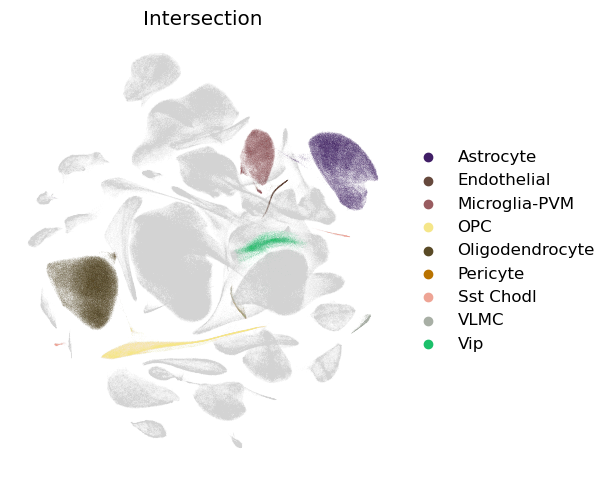

In [43]:
with plt.rc_context({"savefig.dpi":600, "figure.figsize":(6,10.5), "font.size":12, 'figure.constrained_layout.use':True}):
    fig, ax = plt.subplots()
    sc.pl.umap(latent_adata, color = "Subclass", frameon = False, title = "Intersection", na_in_legend = False, show = False, ax = ax, palette = custom_palette)
    ax.set_aspect("equal")
    plt.savefig("/scratch/figure1_umap_intersection.png", bbox_inches="tight",)
    plt.show()

In [44]:
del latent_adata.obs["Subclass"]

In [46]:
subclass_df = pd.concat([reference_obs["Subclass"], query_obs["Subclass"]]).str.replace("MSN", "SPN")

In [47]:
latent_adata.obs = latent_adata.obs.merge(subclass_df, left_index = True, right_index = True, how = "left").copy()

In [48]:
latent_adata.obs.loc[latent_adata.obs["mixed_cluster"], "Subclass"] = np.nan

In [49]:
latent_adata.obs.loc[latent_adata.obs["dataset"] == "HMBA Caudate Nucleus", "Subclass"] = np.nan

In [50]:
cell_counts = latent_adata.obs["Subclass"].value_counts()
include_cells = cell_counts[cell_counts > 500].index.tolist()
latent_adata.obs["Subclass"] = latent_adata.obs["Subclass"].apply(lambda x: x if x in include_cells else np.nan)

In [51]:
latent_adata.obs["Subclass"] = latent_adata.obs["Subclass"].replace({"Endo":"Endothelial", "Microglia":"Microglia-PVM",}).copy()

## Figure 1F-3

In [52]:
with plt.rc_context({"savefig.dpi":600}):
    sc.pl.umap(latent_adata, color = "Subclass", frameon = False, title = "SEA-AD MTG Only", legend_loc = "on data", show = False, na_in_legend= False)
    plt.savefig("/results/figure1_umap_mtg_only.png", bbox_inches="tight",)

... storing 'Subclass' as categorical
/opt/conda/lib/python3.12/site-packages/scanpy/plotting/_tools/scatterplots.py:1227: FutureWarning: The method obs_vector is deprecated and will be removed in the future. Use anndata.acc.A instead of obs_vector. E.g. `vec = adata[A.obs['foo']]` or `vec = adata[A.layers['l']['bar', :]]`
  values = adata.obs_vector(value_to_plot, layer=layer)


In [53]:
del latent_adata.obs["Subclass"]

In [54]:
subclass_df = pd.concat([reference_obs["Subclass"], query_obs["Subclass"]]).str.replace("MSN", "SPN")

In [55]:
latent_adata.obs = latent_adata.obs.merge(subclass_df, left_index = True, right_index = True, how = "left").copy()

In [56]:
latent_adata.obs.loc[latent_adata.obs["mixed_cluster"], "Subclass"] = np.nan

In [57]:
latent_adata.obs.loc[latent_adata.obs["dataset"] == "SEA-AD MTG", "Subclass"] = np.nan

In [58]:
cell_counts = latent_adata.obs["Subclass"].value_counts()
include_cells = cell_counts[cell_counts > 600].index.tolist()
latent_adata.obs["Subclass"] = latent_adata.obs["Subclass"].apply(lambda x: x if x in include_cells else np.nan)

In [59]:
latent_adata.obs["Subclass"] = latent_adata.obs["Subclass"].replace({"Endo":"Endothelial", "Microglia":"Microglia-PVM"}).copy()

In [60]:
latent_adata.obs["Subclass"].unique()

array(['Ependymal', 'STR D2 SPN', 'STR Hybrid SPN', nan, 'STR D1 SPN',
       'CN ST18 GABA', 'CN VIP GABA', 'STR RSPO2 GABA'], dtype=object)

In [61]:
latent_adata[latent_adata.obs['Subclass'].isin(include_cells)].obs[['Group', 'Subclass_scANVI']]

KeyError: "None of [Index(['Group', 'Subclass_scANVI'], dtype='object')] are in the [columns]"

In [62]:
custom_palette = {'Ependymal':"#564860", 'STR D2 SPN':'#253c8c', 'STR Hybrid SPN':'#79bdf4', 'STR D1 SPN':'#1655f2',
       'Ca ST18 GABA':'#5fd989', 'Ca VIP GABA':'#1bc06a', 'STR RSPO2 GABA':'#5b0e63'}

In [63]:
latent_adata.obs['Subclass'] = latent_adata.obs['Subclass'].str.replace("CN", "Ca") 

/opt/conda/lib/python3.12/site-packages/scanpy/plotting/_tools/scatterplots.py:1227: FutureWarning: The method obs_vector is deprecated and will be removed in the future. Use anndata.acc.A instead of obs_vector. E.g. `vec = adata[A.obs['foo']]` or `vec = adata[A.layers['l']['bar', :]]`
  values = adata.obs_vector(value_to_plot, layer=layer)


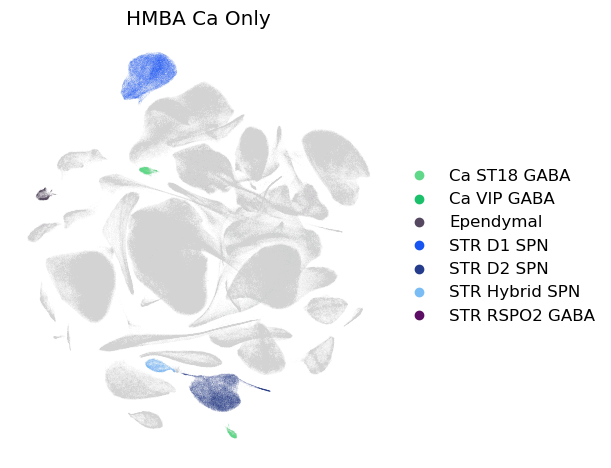

In [65]:
with plt.rc_context({"savefig.dpi":600, "figure.figsize":(6,10.5), "font.size":12, 'figure.constrained_layout.use':True}):
    fig, ax = plt.subplots()
    sc.pl.umap(latent_adata, color = "Subclass", frameon = False, title = "HMBA Ca Only", show = False, na_in_legend = False, palette = custom_palette, ax = ax)
    ax.set_aspect("equal")
    plt.savefig("/scratch/figure1_umap_hmba_only.png", bbox_inches="tight",)
    plt.show()

## Figure 1G

In [66]:
latent_adata_subset = latent_adata[~latent_adata.obs["mixed_cluster"]]

In [67]:
latent_adata_subset.obs["Class_scANVI"].value_counts()

Class_scANVI
Neuronal: Glutamatergic        852607
Neuronal: GABAergic            352473
Non-neuronal and Non-neural      4597
Name: count, dtype: int64

In [68]:
def read_obs(path):
    with File(path) as f:
        return read_elem(f['obs'])

In [69]:
combined_reference_obs = read_obs("/data/reference_adata/20250625_CN_MTG_HMBA_SEAAD_Combined_Reference.h5ad")

FileNotFoundError: [Errno 2] Unable to synchronously open file (unable to open file: name = '/data/reference_adata/20250625_CN_MTG_HMBA_SEAAD_Combined_Reference.h5ad', errno = 2, error message = 'No such file or directory', flags = 0, o_flags = 0)

In [70]:
combined_reference_obs = combined_reference_obs[combined_reference_obs.apply(lambda x: x['Group'] != x['Supertype'], axis = 1)]

NameError: name 'combined_reference_obs' is not defined

In [71]:
combined_counts = combined_reference_obs[['Group', 'Supertype']].dropna().value_counts().reset_index()

In [72]:
combined_counts

,Group,Supertype,count
0,Oligo OPALIN,Oligo_2,20368
1,STR Astrocyte,Astro_2,12407
2,Microglia,Micro-PVM_2,9390
3,Oligo RBFOX1,Oligo_1,5971
4,STR Astrocyte,Astro_3,4069
...,...,...,...
127,BG Cholinergic GABA,Pericyte_1,1
128,BG LAMP5-CXCL14 GABA,Micro-PVM_2_3-SEAAD,1
129,COP,Oligo_3,1
130,COP,Oligo_4,1


In [73]:
combined_counts_table = combined_counts.pivot(columns = "Group", index = "Supertype", values = "count").fillna(0).astype(int)
combined_counts_table = combined_counts_table.loc[combined_counts_table.sum(axis = 1) > 10, combined_counts_table.sum(axis = 0) > 10]

In [74]:
comb_counts_table = (combined_counts_table / combined_counts_table.sum())

In [75]:
comb_counts_table = comb_counts_table.sort_index()

In [76]:
col_order = comb_counts_table.apply(lambda x: np.argsort(x)[-1], axis = 0).sort_values().index

/tmp/ipykernel_272/1565361217.py:1: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  col_order = comb_counts_table.apply(lambda x: np.argsort(x)[-1], axis = 0).sort_values().index
/tmp/ipykernel_272/1565361217.py:1: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  col_order = comb_counts_table.apply(lambda x: np.argsort(x)[-1], axis = 0).sort_values().index
/tmp/ipykernel_272/1565361217.py:1: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  

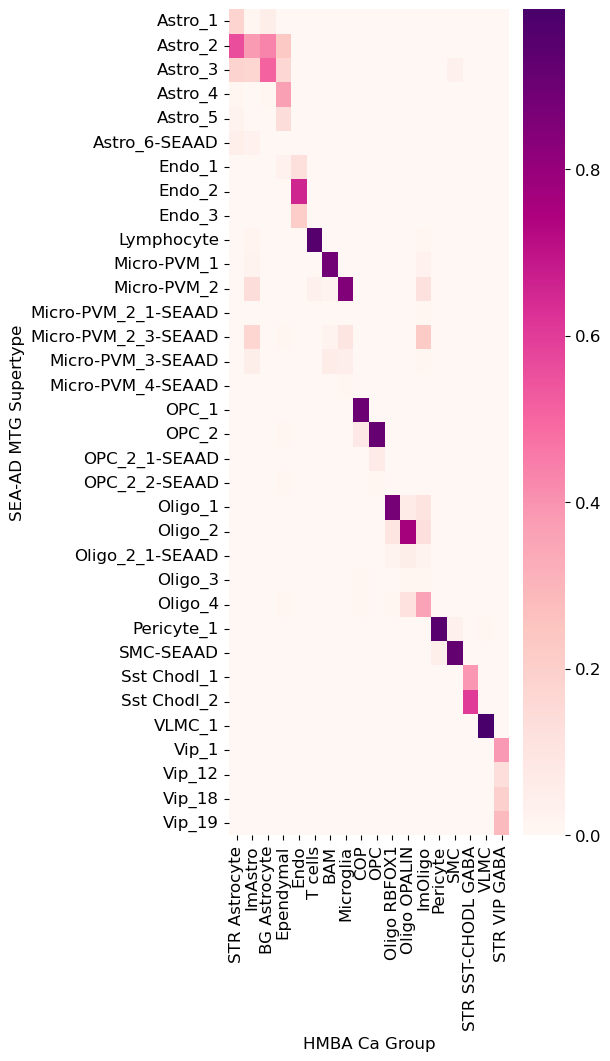

In [82]:
with plt.rc_context({"savefig.dpi":600, "figure.figsize":(6,10.5), "font.size":12, 'figure.constrained_layout.use':True}):
    ax =sns.heatmap(data = comb_counts_table.loc[:, col_order], xticklabels = True, yticklabels = True, cmap = "RdPu",)
    ax.set_ylabel("SEA-AD MTG Supertype")
    ax.set_xlabel("HMBA Ca Group")
    plt.savefig("/scratch/figure1_hmba_to_seaad.svg", bbox_inches="tight",)
    plt.show()